## Regime Aware Parameter Optimizer

The goal of the optimizer is to answer the following questions:
- Does adaptive parameter selection yield higher cumulative P&L?

Backtesting will be completed for the following scenarios:
- Fixed: always use Conservative params → cumulative P&L
- Adaptive: MLP-predicted preset per entry → cumulative P&L
- Oracle: best-in-hindsight preset per entry → cumulative P&L (ceiling)

Preset Trade Parameters:
- "Aggressive":   {"stop": 1.0, "target": 2.0,  "hold": 12},
- "Moderate":     {"stop": 0.75,  "target": 1.0,  "hold": 9},
- "Conservative": {"stop": 0.5,  "target": 0.75, "hold": 6},
- "Defensive":    {"stop": 0.5,  "target": 0.5, "hold": 3}

Baseline Trading system will utilize the "Conservative" trade parameters.

In [34]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

### Validate Data

In [13]:
# trade constraints
RISK_PER_TRADE = 1_000
FIXED_PRESET   = "Conservative"

PRESETS = ["Aggressive", "Moderate", "Conservative", "Defensive"]

REGIME_LABELS = {
    0: "Trending",
    1: "Choppy",
    2: "Range Bound",
    3: "Flat",
}

FEATURE_COLS = [
    "ret_1","ret_3","ret_6","ret_12","ret_18","ret_24",
    "atr_12","atr_pct_12",
    "vwap_session","vwap_dist","vwap_dist_atr",
    "vol_ratio_18",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "rv_12",
    "tod_sin","tod_cos",
]

REGIME_PROB_COLS = ["prob_trending","prob_choppy","prob_range_bound","prob_flat"]

In [14]:
# load files
entries = pd.read_csv("multiasset_labeled_entries_with_transformer_preds.csv")

# parse timestamps as UTC
for col in ["ts_signal", "ts_entry", "best_exit_ts"]:
    entries[col] = pd.to_datetime(entries[col], utc=True)

print(f"Total entries: {len(entries)}")
print(f"Columns: {entries.columns.tolist()}\n")

Total entries: 1508
Columns: ['symbol', 'ts_signal', 'ts_entry', 'entry_price', 'entry_atr', 'ret_1', 'ret_3', 'ret_6', 'ret_12', 'ret_18', 'ret_24', 'atr_12', 'atr_pct_12', 'vwap_session', 'vwap_dist', 'vwap_dist_atr', 'vol_ratio_18', 'range_pct', 'body_pct', 'upper_wick_pct', 'lower_wick_pct', 'rv_12', 'tod_sin', 'tod_cos', 'best_param_id', 'best_R', 'best_exit_reason', 'best_exit_price', 'best_exit_ts', 'best_stop_atr', 'best_target_atr', 'best_hold_bars', 'best_preset', 'R_Aggressive', 'R_Moderate', 'R_Conservative', 'R_Defensive', 'fixed_R', 'fixed_exit_price', 'fixed_exit_reason', 'fixed_preset', 'risk_per_trade', 'side', 'split', 'session_date', 'macro_regime_id', 'regime_label', 'pred_regime_id', 'prob_flat', 'prob_trending', 'prob_choppy', 'prob_range_bound', 'pred_regime_source']



In [15]:
# split data
print("Split counts:")
print(entries["split"].value_counts().sort_index())

print("\nDate ranges by split:")
for s in ["train", "val", "test"]:
    sub = entries[entries["split"] == s]
    print(f"  {s:5s}: {sub['ts_entry'].min().date()} → {sub['ts_entry'].max().date()}  ({len(sub)} trades)")

Split counts:
split
test      243
train    1023
val       242
Name: count, dtype: int64

Date ranges by split:
  train: 2024-04-11 → 2025-07-15  (1023 trades)
  val  : 2025-07-15 → 2025-10-27  (242 trades)
  test : 2025-10-28 → 2026-02-27  (243 trades)


07/15/2025 is also included in train, need to fix

In [16]:
# check regimes
print("\npred_regime_id distribution:")
print(entries["pred_regime_id"].value_counts())

print("\npred_regime_source distribution:")
print(entries["pred_regime_source"].value_counts())


pred_regime_id distribution:
pred_regime_id
1.0    576
3.0    456
2.0    335
0.0    141
Name: count, dtype: int64

pred_regime_source distribution:
pred_regime_source
transformer            1497
rule_based_fallback      11
Name: count, dtype: int64


In [17]:
# check labels
print("\nbest_preset distribution (all):")
print(entries["best_preset"].value_counts())

print("\nbest_preset distribution by split:")
print(entries.groupby("split")["best_preset"].value_counts().unstack(fill_value=0))


best_preset distribution (all):
best_preset
Aggressive      828
Conservative    396
Moderate        233
Defensive        51
Name: count, dtype: int64

best_preset distribution by split:
best_preset  Aggressive  Conservative  Defensive  Moderate
split                                                     
test                123            65         14        41
train               579           263         29       152
val                 126            68          8        40


In [18]:
# check NaN features
nan_counts = entries[FEATURE_COLS].isna().sum()
nan_cols   = nan_counts[nan_counts > 0]
if len(nan_cols):
    print("\nNaNs in feature cols:")
    print(nan_cols)
else:
    print("\nNo NaNs in feature columns.")


No NaNs in feature columns.


In [19]:
# check NaN in preset R columns
r_cols = ["R_Aggressive","R_Moderate","R_Conservative","R_Defensive","fixed_R"]
print("\nNaN counts in R columns:")
print(entries[r_cols].isna().sum())


NaN counts in R columns:
R_Aggressive      0
R_Moderate        0
R_Conservative    0
R_Defensive       0
fixed_R           0
dtype: int64


In [20]:
# verify regime probabilities
missing_prob_cols = [c for c in REGIME_PROB_COLS if c not in entries.columns]
if missing_prob_cols:
    print(f"\nmissing regime prob cols: {missing_prob_cols}")
    print("columns containing 'prob':", [c for c in entries.columns if "prob" in c.lower()])
else:
    print(f"\nRegime prob cols: {REGIME_PROB_COLS}")


Regime prob cols: ['prob_trending', 'prob_choppy', 'prob_range_bound', 'prob_flat']


In [21]:
# fix data split
entries["date_ny"] = entries["ts_entry"].dt.tz_convert("America/New_York").dt.date

# sort chronologically
unique_dates = sorted(entries["date_ny"].unique())
n_dates      = len(unique_dates)

train_end_idx = int(n_dates * 0.70)
val_end_idx   = int(n_dates * 0.85)

train_dates = set(unique_dates[:train_end_idx])
val_dates   = set(unique_dates[train_end_idx:val_end_idx])
test_dates  = set(unique_dates[val_end_idx:])

def assign_split(d):
    if d in train_dates: return "train"
    if d in val_dates:   return "val"
    return "test"

entries["split"] = entries["date_ny"].apply(assign_split)

# verify splits
print(f"Total unique dates : {n_dates}")
print(f"Train dates        : {len(train_dates)}  ({min(train_dates)} → {max(train_dates)})")
print(f"Val dates          : {len(val_dates)}   ({min(val_dates)} → {max(val_dates)})")
print(f"Test dates         : {len(test_dates)}   ({min(test_dates)} → {max(test_dates)})")

print("\nSplit entry counts (after date-based reassignment):")
print(entries["split"].value_counts().sort_index())

Total unique dates : 421
Train dates        : 294  (2024-04-11 → 2025-07-18)
Val dates          : 63   (2025-07-21 → 2025-10-28)
Test dates         : 64   (2025-10-29 → 2026-02-27)

Split entry counts (after date-based reassignment):
split
test      238
train    1038
val       232
Name: count, dtype: int64


### Feature Engineering for MLP Model

In [45]:
# one-hot encode regimes
regime_dummies = pd.get_dummies(entries["pred_regime_id"], prefix="regime")
print("Regime dummy cols:", regime_dummies.columns.tolist())

symbol_dummies = pd.get_dummies(entries["symbol"], prefix="sym")
print("Symbol dummy cols:", symbol_dummies.columns.tolist())

# create feature matrix
all_feature_cols = FEATURE_COLS + list(regime_dummies.columns) + REGIME_PROB_COLS + list(symbol_dummies.columns)


X_full = pd.concat(
    [entries[FEATURE_COLS].reset_index(drop=True),
     regime_dummies.reset_index(drop=True),
     entries[REGIME_PROB_COLS].reset_index(drop=True),
     symbol_dummies.reset_index(drop=True)],
    axis=1
)

# encode target
le = LabelEncoder()
le.fit(PRESETS)
y_full = le.transform(entries["best_preset"])

print(f"Classes: {le.classes_}  →  {list(range(len(le.classes_)))}")
print(f"Feature matrix shape: {X_full.shape}")

Regime dummy cols: ['regime_0.0', 'regime_1.0', 'regime_2.0', 'regime_3.0']
Symbol dummy cols: ['sym_COIN', 'sym_NVDA', 'sym_OKLO', 'sym_PLTR', 'sym_TSLA']
Classes: ['Aggressive' 'Conservative' 'Defensive' 'Moderate']  →  [0, 1, 2, 3]
Feature matrix shape: (1508, 32)


In [46]:
# create datasets
train_mask = entries["split"] == "train"
val_mask   = entries["split"] == "val"
test_mask  = entries["split"] == "test"

X_train, y_train = X_full[train_mask].values, y_full[train_mask]
X_val,   y_val   = X_full[val_mask].values,   y_full[val_mask]
X_test,  y_test  = X_full[test_mask].values,  y_full[test_mask]

In [47]:
# scale features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}  y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  y_test : {y_test.shape}")


X_train: (1038, 32)  y_train: (1038,)
X_val  : (232, 32)  y_val  : (232,)
X_test : (238, 32)  y_test : (238,)


### MLP Model Training

Given the imbalance class distribution, class weights will be needed

In [48]:
# compute class weights
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
sample_weights    = np.array([class_weight_dict[y] for y in y_train])

print("Class weights:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls:12s} → {class_weight_dict[i]:.4f}")

Class weights:
  Aggressive   → 0.4421
  Conservative → 0.9611
  Defensive    → 8.9483
  Moderate     → 1.7072


In [49]:
# train MLP
mlp = MLPClassifier(
    hidden_layer_sizes  = (128, 64, 32),
    activation          = "relu",
    solver              = "adam",
    alpha               = 0.01,
    learning_rate_init  = 0.001,
    max_iter            = 1000,
    early_stopping      = True,
    validation_fraction = 0.1,
    n_iter_no_change    = 50,
    random_state        = 42,
    verbose             = False,
)

mlp.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nTraining stopped at: {mlp.n_iter_}")
print(f"Best val score:     {mlp.best_validation_score_:.4f}")


Training stopped at: 66
Best val score:     0.3225


In [50]:
# check MLP accuracy
train_acc = mlp.score(X_train, y_train)
val_acc   = mlp.score(X_val,   y_val)
test_acc  = mlp.score(X_test,  y_test)

print(f"\nAccuracy — Train: {train_acc:.4f}  |  Val: {val_acc:.4f}  |  Test: {test_acc:.4f}")



Accuracy — Train: 0.4249  |  Val: 0.2543  |  Test: 0.3193


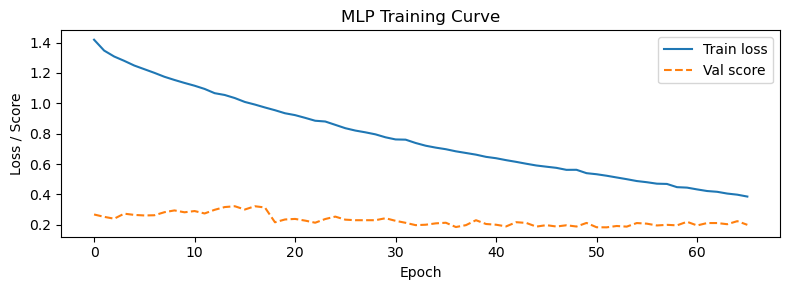

In [51]:
# check loss curve
plt.figure(figsize=(8, 3))
plt.plot(mlp.loss_curve_, label="Train loss")
if hasattr(mlp, "validation_scores_"):
    plt.plot(mlp.validation_scores_, label="Val score", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss / Score")
plt.title("MLP Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# check test prediction distribution
mlp_preds_test = mlp.predict(X_test)
unique, counts = np.unique(mlp_preds_test, return_counts=True)
print("MLP test predictions:")
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]:12s}: {c}")

MLP test predictions:
  Aggressive  : 83
  Conservative: 64
  Defensive   : 44
  Moderate    : 47


In [53]:
# check actual test distribution
print("\nActual test distribution:")
for p in PRESETS:
    n = (entries[test_mask]["best_preset"] == p).sum()
    print(f"  {p:12s}: {n}")


Actual test distribution:
  Aggressive  : 121
  Moderate    : 39
  Conservative: 65
  Defensive   : 13


### Model Evaluation

Classification Report — Test Set
              precision    recall  f1-score   support

  Aggressive      0.530     0.364     0.431       121
Conservative      0.312     0.308     0.310        65
   Defensive      0.068     0.231     0.105        13
    Moderate      0.191     0.231     0.209        39

    accuracy                          0.319       238
   macro avg      0.276     0.283     0.264       238
weighted avg      0.390     0.319     0.344       238



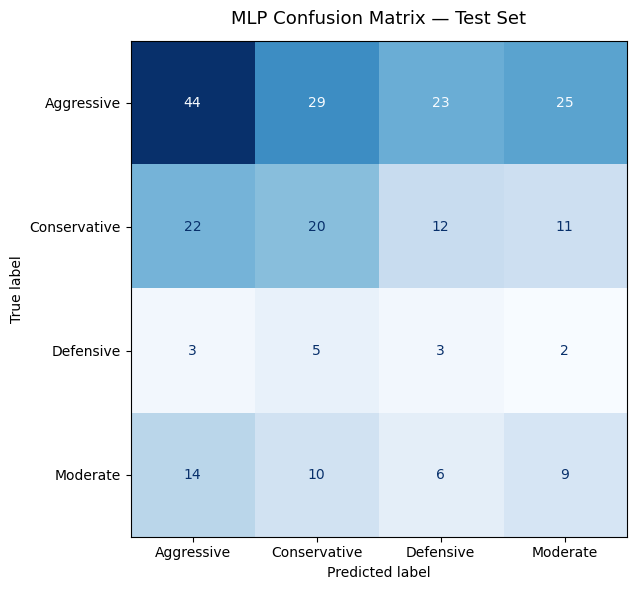


Per-preset recall (how often we correctly identify each preset):
  Aggressive  : 44/121  (36.4%)
  Conservative: 20/65  (30.8%)
  Defensive   : 3/13  (23.1%)
  Moderate    : 9/39  (23.1%)


In [54]:
mlp_preds_test = mlp.predict(X_test)

# classification report
print("Classification Report — Test Set")
print("=" * 50)
print(classification_report(
    y_test, mlp_preds_test,
    target_names=le.classes_,
    digits=3
))

# confusion matrix
cm = confusion_matrix(y_test, mlp_preds_test, labels=range(len(le.classes_)))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("MLP Confusion Matrix — Test Set", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print("\nPer-preset recall (how often we correctly identify each preset):")
for i, name in enumerate(le.classes_):
    correct = ((y_test == i) & (mlp_preds_test == i)).sum()
    total   = (y_test == i).sum()
    print(f"  {name:12s}: {correct}/{total}  ({correct/total*100:.1f}%)")

### P&L Simulation

In [78]:
# test data with MLP predictions
test_entries = entries[test_mask].copy().reset_index(drop=True)
test_entries["mlp_pred_preset"] = le.classes_[mlp_preds_test]

R_COL = {
    "Aggressive":   "R_Aggressive",
    "Moderate":     "R_Moderate",
    "Conservative": "R_Conservative",
    "Defensive":    "R_Defensive",
}

flat_mask = test_entries["pred_regime_id"] == 3
print(f"Flat trades to skip: {flat_mask.sum()}")

Flat trades to skip: 66


In [79]:
# fixed parameters
test_entries["pnl_fixed"] = test_entries["fixed_R"] * RISK_PER_TRADE

In [80]:
# adaptive parameters
adaptive_r = pd.Series(np.nan, index=test_entries.index)
for preset, col in R_COL.items():
    mask = (test_entries["mlp_pred_preset"] == preset) & ~flat_mask
    adaptive_r[mask] = test_entries.loc[mask, col]
test_entries["pnl_adaptive"] = adaptive_r * RISK_PER_TRADE

In [81]:
# oracle parameters
oracle_r = pd.Series(np.nan, index=test_entries.index)
for preset, col in R_COL.items():
    mask = (test_entries["best_preset"] == preset) & ~flat_mask
    oracle_r[mask] = test_entries.loc[mask, col]
test_entries["pnl_oracle"] = oracle_r * RISK_PER_TRADE

In [87]:
# sort and calc P&L
test_entries = test_entries.sort_values("ts_entry").reset_index(drop=True)

test_entries["cum_pnl_fixed"]    = test_entries["pnl_fixed"].cumsum()
test_entries["cum_pnl_adaptive"] = test_entries["pnl_adaptive"].cumsum()
test_entries["cum_pnl_oracle"]   = test_entries["pnl_oracle"].cumsum()

print(f"{'='*58}")
print(f"{'Strategy':<14} {'Total P&L':>10} {'Trades':>7} {'Win%':>7} {'Avg R':>8} {'Skipped':>8}")
print(f"{'='*58}")

for strat, pnl_col in [("Fixed", "pnl_fixed"), ("Adaptive", "pnl_adaptive"), ("Oracle", "pnl_oracle")]:
    traded   = test_entries[test_entries[pnl_col].notna()]
    skipped  = test_entries[pnl_col].isna().sum()
    total    = traded[pnl_col].sum()
    n        = len(traded)
    win_pct  = (traded[pnl_col] > 0).sum() / n * 100 if n > 0 else 0
    avg_r    = traded[pnl_col].mean() / RISK_PER_TRADE if n > 0 else 0
    print(f"{strat:<14} ${total:>9,.0f} {n:>7} {win_pct:>6.1f}% {avg_r:>8.3f}R {skipped:>8}")

print(f"{'='*58}")
print(f"\nAdaptive preset selection breakdown:")
print(test_entries[test_entries["pnl_adaptive"].notna()]["mlp_pred_preset"].value_counts())

Strategy        Total P&L  Trades    Win%    Avg R  Skipped
Fixed          $  -26,505     238   35.7%   -0.111R        0
Adaptive       $  -20,737     172   37.2%   -0.121R       66
Oracle         $   73,595     172   54.1%    0.428R       66

Adaptive preset selection breakdown:
mlp_pred_preset
Conservative    58
Aggressive      41
Defensive       40
Moderate        33
Name: count, dtype: int64


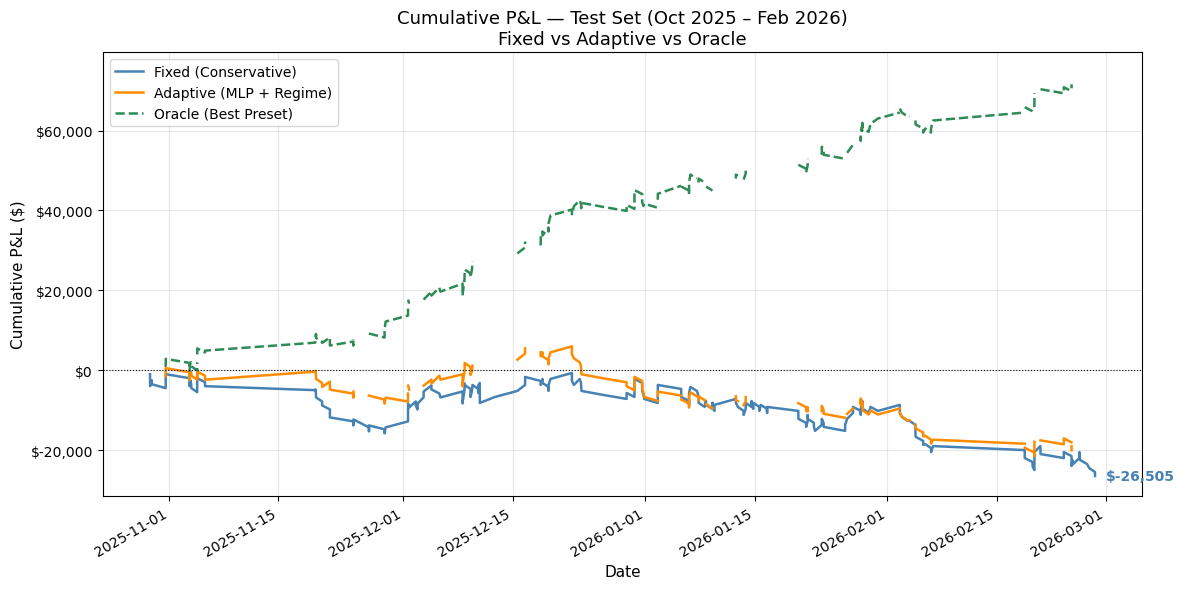

In [89]:
# plot P&L
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(test_entries["ts_entry"], test_entries["cum_pnl_fixed"],
        label="Fixed (Conservative)", color="steelblue", linewidth=1.8)
ax.plot(test_entries["ts_entry"], test_entries["cum_pnl_adaptive"],
        label="Adaptive (MLP + Regime)", color="darkorange", linewidth=1.8)
ax.plot(test_entries["ts_entry"], test_entries["cum_pnl_oracle"],
        label="Oracle (Best Preset)", color="seagreen", linewidth=1.8, linestyle="--")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")

flat_entries = test_entries[test_entries["pred_regime_id"] == 3]
for _, row in flat_entries.iterrows():
    ax.axvspan(row["ts_entry"], row["ts_entry"],
               alpha=0.08, color="gray", linewidth=0)

for label, col, color in [
    ("Fixed",    "cum_pnl_fixed",    "steelblue"),
    ("Adaptive", "cum_pnl_adaptive", "darkorange"),
    ("Oracle",   "cum_pnl_oracle",   "seagreen"),
]:
    final_val = test_entries[col].iloc[-1]
    ax.annotate(
        f"${final_val:,.0f}",
        xy=(test_entries["ts_entry"].iloc[-1], final_val),
        xytext=(8, 0), textcoords="offset points",
        color=color, fontsize=10, fontweight="bold", va="center"
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Cumulative P&L ($)", fontsize=11)
ax.set_title("Cumulative P&L — Test Set (Oct 2025 – Feb 2026)\nFixed vs Adaptive vs Oracle", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()